# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python15 - Support Vector Machine (SVM)</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **🔹 What is a Support Vector Machine (SVM)?**
Support Vector Machine (SVM) is a **supervised learning algorithm** used for classification and regression tasks. SVM is particularly effective in high-dimensional spaces and for cases where the number of dimensions exceeds the number of samples.

SVM aims to find the **optimal decision boundary** that best separates data into different classes. This boundary is known as the **hyperplane**.

---

## **🔹 Mathematical Formulation of SVM**
The goal of SVM is to maximize the **margin** between different classes while minimizing classification error.

### **1️⃣ Hyperplane Equation**
A hyperplane in an **n-dimensional space** is defined as:

$$ w \cdot x + b = 0 $$

where:
- $ w $ is the **weight vector** (normal to the hyperplane),
- $ x $ is the **feature vector**,
- $ b $ is the **bias term**.

---

### **2️⃣ Hard Margin SVM (for Linearly Separable Data)**
For a dataset **with two classes** labeled as $ y_i \in \{-1,1\} $, we define the constraints:

$$ y_i (w \cdot x_i + b) \geq 1, \quad \forall i $$

The objective is to **maximize the margin**, which is equivalent to minimizing:

$$ \frac{1}{2} ||w||^2 $$

subject to the constraint above.

---

### **3️⃣ Soft Margin SVM (for Non-Separable Data)**
In real-world datasets, perfect separation may not be possible. To handle misclassification, **slack variables** ($\xi_i$) are introduced:

$$ y_i (w \cdot x_i + b) \geq 1 - \xi_i, \quad \forall i $$

The optimization problem becomes:

$$ \min_{w,b,\xi} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \xi_i $$

where:
- $ C $ is the **regularization parameter** that controls the trade-off between maximizing the margin and allowing classification errors.

---

### **4️⃣ Kernel Trick for Non-Linear Data**
SVM can be extended to **non-linearly separable data** using the **kernel trick**. Instead of working in the original feature space, we **map data to a higher-dimensional space** where it becomes linearly separable.


![example](https://miro.medium.com/v2/resize:fit:656/0*KGkhQkRwthxW_Txz.png)

Common kernels:
- **Linear Kernel**: $ K(x_i, x_j) = x_i \cdot x_j $
- **Polynomial Kernel**: $ K(x_i, x_j) = (x_i \cdot x_j + c)^d $
- **Radial Basis Function (RBF) Kernel**:  
  $$ K(x_i, x_j) = \exp\left(-\gamma ||x_i - x_j||^2\right) $$
- **Sigmoid Kernel**:  
  $$ K(x_i, x_j) = \tanh(\alpha x_i \cdot x_j + c) $$



---

## **🔹 Advantages of SVM**
✅ Works well in **high-dimensional spaces**.  
✅ Effective for **small datasets**.  
✅ Can model **non-linear relationships** using kernel functions.  
✅ Robust to **overfitting**, especially with proper parameter tuning.

## **🔹 Disadvantages of SVM**
❌ Computationally expensive for **large datasets**.  
❌ Difficult to interpret results compared to decision trees.  
❌ Choice of kernel and hyperparameters requires careful tuning.

---

## **🔹 Visualizing SVM with Different Kernels**
![SVM Kernel Trick](https://scikit-learn.org/stable/_images/sphx_glr_plot_iris_svc_001.png)


---


# Data Loading

In [ ]:
#%%
import pandas as pd
data = pd.read_csv('diabetes.csv')

In [ ]:
X = data.iloc[:,0:-1]
column_names = list(X) 
y = data.iloc[:,-1] 

from sklearn.model_selection import train_test_split

#SPLIT DATA INTO TRAIN AND TEST SET
X_train, X_test, y_train, y_test = train_test_split(X, y,  #X_scaled
                                                    test_size =0.30, #by default is 75%-25%
                                                    #shuffle is set True by default,
                                                    stratify=y,
                                                    random_state= 123) #fix random seed for replicability

print(X_train.shape)

(537, 8)


# SVM model

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### 📌 **Exercise: Hyperparameter Tuning and Evaluation of an SVM Classifier**




### **📝 Step 1: Define the SVM Classifier and Hyperparameter Grid**
We will tune the following **hyperparameters** (You can remove some elements to reduce the time):
- **Kernel**: `linear`, `rbf`, `polynomial`
- **Regularization parameter (C)**: Controls trade-off between margin maximization and misclassification.
- **Gamma (for RBF kernel)**: Defines how far influence of a single example reaches.
- **Degree (for polynomial kernel)**: Degree of the polynomial function.


---

### **📝 Step 2: Evaluate the Best Model**
Once the best hyperparameters are selected, **evaluate** the model on the test set.


---

### **📝 Step 3: Compute and Plot the ROC Curve**
ROC curve measures model performance for **binary classification problems**. If working with **multi-class**, modify the approach to **One-vs-Rest (OvR).**


---

## **💡 Tasks for You**
1. **Modify the parameter grid**:
   - Add more values for `C`, `gamma`, and `degree` to see their effects.
   - Try different kernels (`sigmoid`, `poly` with higher degrees).
   
2. **Interpret the Results**:
   - Compare **classification reports** for different kernels.
   - What kernel works best for this dataset? Why?

3. **Extend to Multi-Class Classification**:
   - Modify the **ROC curve computation** to support multi-class classification.

---

🚀 **Try different datasets and see how SVM performs in various scenarios!** 🎯

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the SVM classifier
classifier = SVC(probability=True)  # Enable probability estimation for ROC curve

# Define parameter grid for tuning
parameters = {
    "kernel": ['linear', 'rbf'],  #"poly"
    "C": [0.1, 1, 100],   
    "gamma": [0.001, 0.01, 1],  
   #"degree": [2, 3, 4]  # Only used when kernel='poly'
}

# Perform Grid Search with 3-fold Cross-Validation
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1_weighted', verbose=10, n_jobs=-1, refit=True)
gs = gs.fit(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


*** GRID SEARCH RESULTS ***
Best score: 0.767407 using {'C': 1, 'gamma': 0.001, 'kernel': 'linear'}
*** Classification Report ***
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.53      0.60        81

    accuracy                           0.75       231
   macro avg       0.73      0.70      0.71       231
weighted avg       0.74      0.75      0.74       231



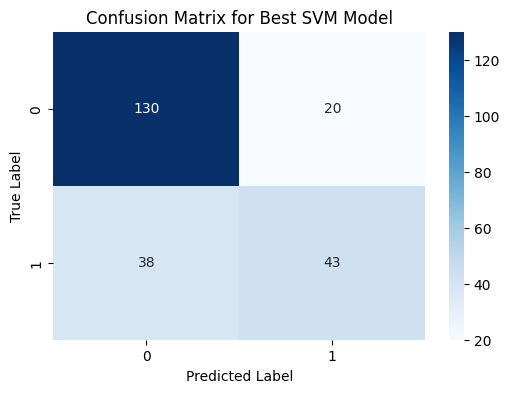

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Print Grid Search results
print('*** GRID SEARCH RESULTS ***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

# Extract the best model
best_model = gs.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

# Display classification report
print("*** Classification Report ***")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Best SVM Model")
plt.show()

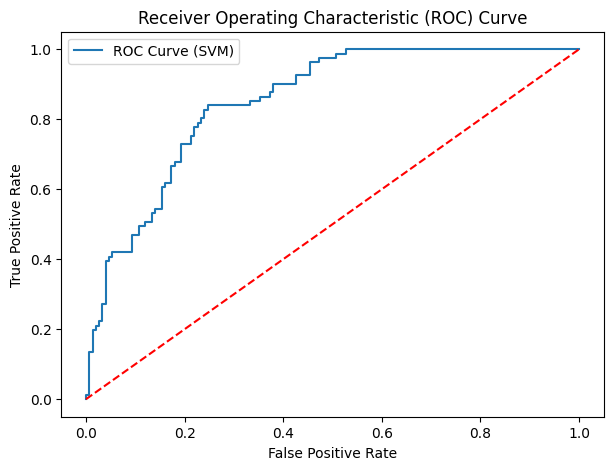

AUC Score: 0.85


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Fit best model with specific parameters
model = SVC(C=0.1, gamma=0.001, kernel='linear', probability=True)
model.fit(X_train, y_train)

# Predict probabilities
y_probs = model.predict_proba(X_test)

# Compute ROC curve (for one class vs rest, use OvR strategy)
fpr, tpr, _ = roc_curve(y_test, y_probs[:, 1], pos_label=1)

# Plot ROC Curve
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label='ROC Curve (SVM)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Compute AUC Score
auc_score = roc_auc_score(y_test, y_probs[:, 1])
print('AUC Score: %.2f' % auc_score)